<a href="https://colab.research.google.com/github/anizamey/week8_lab/blob/main/transfer_learning_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning with Pre-Trained CNN Models in PyTorch: Feature Extraction vs. Fine-Tuning (VGG16 & ResNet50 on CIFAR-10)


### Learning Objectives (beginner-friendly)
- See **why** we reuse ImageNet models for small images (CIFAR-10).
- Load ready-made **VGG16** and **ResNet50** from `torchvision` and change the **last layer** to 10 classes.
- Run a simple **training loop**: forward → loss → backward → optimizer step.
- Try **feature extraction** (train head only) vs **fine-tuning** (train head + last blocks).
- Complete **three exercises**: each has a **coding** part plus **written questions** (minimum **100 words** each).

**Total Marks:** **100** (see each exercise for breakdown)

## Table of Contents

1. [Title & Overview](#lab-4-transfer-learning-with-pre-trained-cnn-models-in-pytorch)
2. [Detailed Tutorial Section](#tutorial-transfer-learning-end-to-end)
3. [Lab Exercises (3 exercises, 100 marks)](#lab-exercises-100-marks)
4. [Conclusion & Submission](#conclusion--submission)


## How to use this notebook (read this first)

- Run cells **from top to bottom** (Shift+Enter). Wait for each cell to finish before the next.
- **GPU:** If you use Google Colab, turn on **Runtime → Change runtime type → GPU**. Training is much faster.
- **Stuck?** Read the **comments** in code cells — they explain what each line does.
- The **tutorial** is copy-paste friendly. The **exercises** ask you to fill in `# TODO` lines using the same patterns.


### PyTorch reminders (very short)

| Idea | What it means |
|------|----------------|
| `tensor` | A multi-dimensional array (like NumPy), often on GPU. |
| `model.to(device)` | Move the network to CPU or GPU. |
| `model.train()` / `model.eval()` | Training mode vs test mode (affects dropout/batch norm). |
| `requires_grad` | If `False`, PyTorch will **not** update those weights (we **freeze** layers). |
| `DataLoader` | Gives you **batches** of images and labels in a loop. |
| `CrossEntropyLoss` | Standard loss for multi-class classification. |

You do **not** need to memorize this — refer back anytime.


---
<a id="tutorial-transfer-learning-end-to-end"></a>
# Detailed Tutorial Section (~60% of notebook)

This section is **fully working**. Run it **in order** like a script. When it runs without errors, you are ready for the exercises below.


## What is Transfer Learning?

Someone already trained a big CNN on **ImageNet** (millions of photos, 1000 classes). That model learned **general** visual skills (edges, shapes, textures).

**Transfer learning** means: take that trained model, **swap the last layer** for our 10 CIFAR-10 classes, and train only what we need. We save time and often get **better accuracy** than training from random weights.


## Pre-trained models we use (names only)

**VGG16** — Older, simple design: many convolution layers in a row, then fully connected layers. Easy to understand.

**ResNet50** — Newer, **deeper** network with **skip connections** (shortcuts that help training). In code it has parts called `layer1` … `layer4`. For fine-tuning we often train **`layer4` + the final `fc` layer**.


## Feature Extraction vs. Fine-Tuning

| Aspect | Feature Extraction | Fine-Tuning |
|--------|-------------------|-------------|
| **What moves?** | Only the new classifier head | Head + selected/top backbone layers |
| **Pros** | Fast, less overfitting risk with small data | Higher accuracy when data is sufficient |
| **Cons** | May underfit if domain differs | More compute; needs smaller LR on backbone |
| **When to use** | Small dataset, similar to ImageNet | More data or domain gap |
| **LR strategy** | Moderate LR on head (e.g., 1e-3) | Smaller LR on backbone (e.g., 1e-4), often larger on head |
| **Compute** | Lower | Higher |


## Step 1 — Imports and device

`device` will be `"cuda"` (GPU) if available, otherwise `"cpu"`. Always send **models** and **data batches** to the same device with `.to(device)`.


In [1]:
# --- Standard libraries ---
import os
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm  # progress bar for training loops

# --- PyTorch core ---
import torch
import torch.nn as nn  # layers like Linear, Conv2d
import torch.optim as optim  # optimizers like SGD, Adam
from torch.utils.data import DataLoader, Subset  # load data in batches

# --- torchvision: datasets + pre-trained models ---
import torchvision
import torchvision.transforms as transforms  # image preprocessing
from torchvision import models  # VGG, ResNet, etc.
from torchvision.datasets import CIFAR10

# Reproducibility (same random numbers each run — good for teaching / debugging)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU found — training will be slower; consider Google Colab with GPU.")


Using device: cuda
GPU name: Tesla T4


## Step 2 — Load CIFAR-10 and resize images

CIFAR-10 images are **32×32**. Pre-trained ImageNet models expect **224×224**, so we **resize**.

We also **normalize** with ImageNet mean/std — this matches how the pre-trained weights were trained.


In [2]:
# Numbers ImageNet models expect (do not change these when using ImageNet weights)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# transforms.Compose chains steps left → right
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((224, 224)),  # make small images bigger for the CNN
        transforms.ToTensor(),  # convert PIL image to tensor, scale 0–1
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    "test": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}

batch_size = 32
# Use num_workers=0 if you see errors on Windows; 2 is OK on many Linux/Mac setups
num_workers = 0

train_set = CIFAR10(root="./data", train=True, download=True, transform=data_transforms["train"])
test_set = CIFAR10(root="./data", train=False, download=True, transform=data_transforms["test"])

train_loader = DataLoader(
    train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available()
)

classes = train_set.classes  # list of 10 class names as strings
print("Class names:", classes)
print("Number of training batches:", len(train_loader), "| test batches:", len(test_loader))


100%|██████████| 170M/170M [00:03<00:00, 49.2MB/s]


Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of training batches: 1563 | test batches: 313


### See the dataset (helps you understand the task)

CIFAR-10 is **10 classes** of small photos (airplane, car, bird, …). Our model will output **one label per image**.

Below we plot images **without** ImageNet normalization so colors look normal on screen. Training still uses the normalized tensors from the cell above.


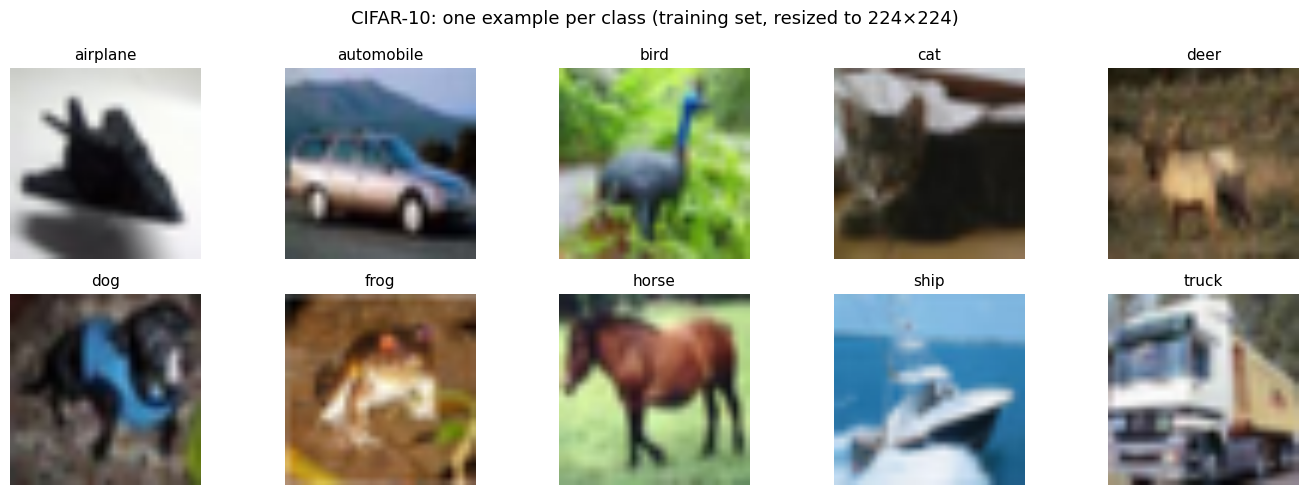

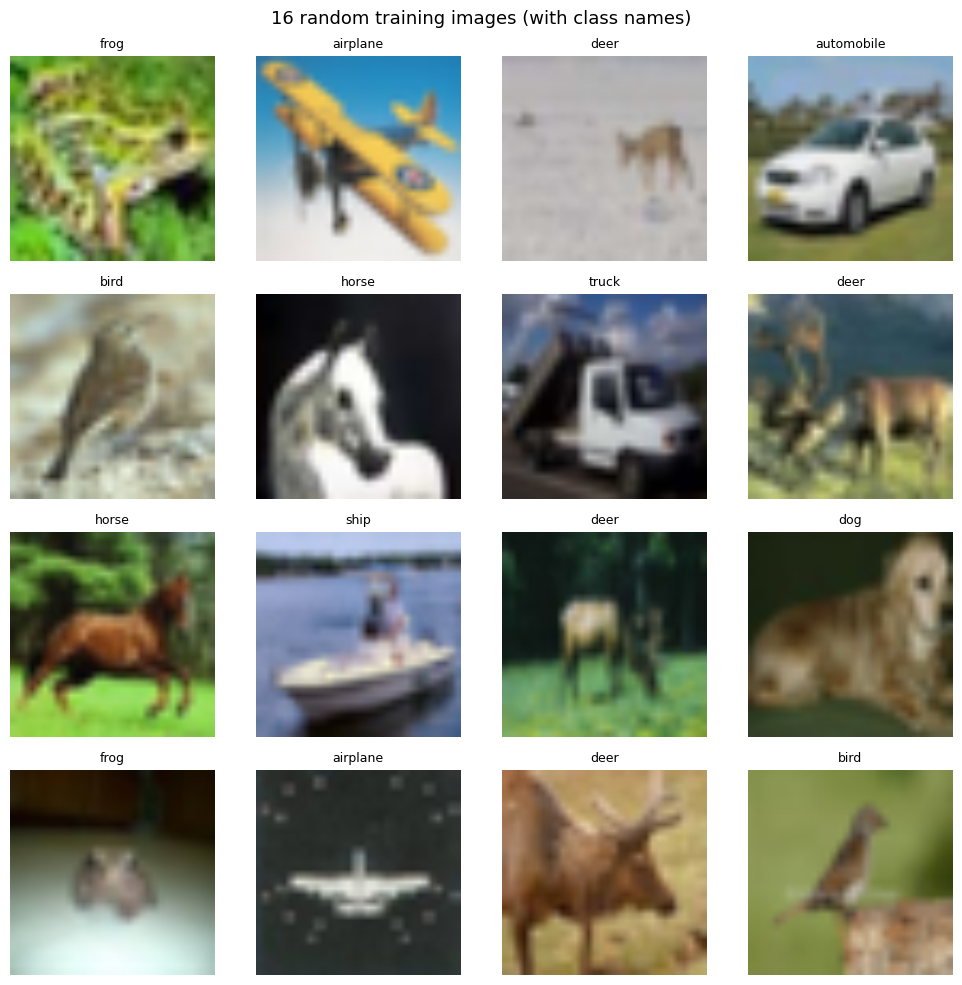

Task: given a 224×224 image like above, predict 1 of 10 class names.


In [3]:
# Visualization-only transforms: resize + tensor in [0, 1] (no Normalize — easier for imshow)
viz_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
viz_train = CIFAR10(root="./data", train=True, download=True, transform=viz_transform)

# --- Figure 1: one training image per class (so you see all 10 labels) ---
one_per_class = {}
for idx in range(len(viz_train)):
    img_t, label = viz_train[idx]
    if label not in one_per_class:
        one_per_class[label] = img_t
    if len(one_per_class) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    img = one_per_class[i]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(classes[i], fontsize=11)
    ax.axis("off")
plt.suptitle("CIFAR-10: one example per class (training set, resized to 224×224)", fontsize=13)
plt.tight_layout()
plt.show()

# --- Figure 2: random mini-batch — shows diversity within classes ---
viz_loader = DataLoader(viz_train, batch_size=16, shuffle=True, num_workers=num_workers)
imgs_batch, labels_batch = next(iter(viz_loader))
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs_batch[i].permute(1, 2, 0).numpy())
    ax.set_title(classes[labels_batch[i]], fontsize=9)
    ax.axis("off")
plt.suptitle("16 random training images (with class names)", fontsize=13)
plt.tight_layout()
plt.show()

print("Task: given a 224×224 image like above, predict 1 of 10 class names.")


## Step 3 — Build models with 10 output classes

We download weights with `weights="IMAGENET1K_V1"`. The last layer was trained for **1000** ImageNet classes; we replace it with **10** for CIFAR-10.

- **VGG16:** the last linear layer is `model.classifier[6]`.
- **ResNet50:** the last layer is `model.fc`.
- **Freeze** = set `requires_grad = False` so those weights are **not** updated during training.


In [4]:
def get_vgg16_feature_extractor(num_classes=10):
    # Load VGG16; freeze convolutional part; only train the small classifier at the end.
    model = models.vgg16(weights="IMAGENET1K_V1")
    for p in model.features.parameters():
        p.requires_grad = False  # freeze all convolution layers
    in_f = model.classifier[6].in_features  # input size of last linear layer
    model.classifier[6] = nn.Linear(in_f, num_classes)  # 10 outputs for CIFAR-10
    return model


def get_resnet50_for_cifar(num_classes=10):
    # Load ResNet50 and replace the final fully connected layer only.
    model = models.resnet50(weights="IMAGENET1K_V1")
    in_f = model.fc.in_features
    model.fc = nn.Linear(in_f, num_classes)
    return model


def count_trainable_parameters(model):
    # How many weights will be updated (smaller = faster, less memory).
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def trainable_params(model):
    # Use this list in optim.SGD(...) — only parameters with requires_grad True.
    return [p for p in model.parameters() if p.requires_grad]


## Step 4 — One training loop you can reuse

`evaluate_model` = measure loss and accuracy **without** updating weights (`torch.no_grad()`).

`train_model` = for each epoch: loop over training batches, **forward → loss → backward → optimizer.step()**, then measure on the test set. This pattern appears in almost every PyTorch classification lab.


In [5]:
def evaluate_model(model, loader, criterion, device):
    # Run on all batches; return average loss and accuracy (no weight updates).
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():  # do not compute gradients — faster and less memory
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)  # class with highest score
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


def train_model(model, train_loader, test_loader, criterion, optimizer, device, num_epochs, scheduler=None, model_name="model"):
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    since = time.time()
    best_acc = 0.0
    best_wts = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}/{num_epochs}")
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()  # clear old gradients
            outputs = model(inputs)  # forward pass
            loss = criterion(outputs, labels)  # compare predictions to true labels
            loss.backward()  # compute gradients
            optimizer.step()  # update weights

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            pbar.set_postfix(loss=loss.item())

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        test_loss, test_acc = evaluate_model(model, test_loader, criterion, device)
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(test_loss)
            else:
                scheduler.step()

        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Epoch {epoch+1}: Train Loss={epoch_loss:.4f} Acc={epoch_acc:.4f} | Test Loss={test_loss:.4f} Acc={test_acc:.4f}")

        if test_acc > best_acc:
            best_acc = test_acc
            best_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed:.1f}s | Best test acc: {best_acc:.4f}")
    model.load_state_dict(best_wts)
    return model, history, time_elapsed, best_acc


## Step 5 — Example A: Feature extraction (VGG16, train the head only)

We only train the **new last layer**. Learning rate **0.001** is a common starting point.

*Tip: we use **3 epochs** below so the tutorial runs quickly on CPU. You can change `TUTORIAL_EPOCHS` to **5** for slightly better curves.*


In [6]:
criterion = nn.CrossEntropyLoss()  # expects raw logits and class indices as labels

TUTORIAL_EPOCHS = 3  # increase to 5 if you have time / GPU

# Feature extraction on VGG16
vgg_fe = get_vgg16_feature_extractor(10).to(device)
print("How many weights will train? (VGG16 feature extraction):", count_trainable_parameters(vgg_fe))

opt_fe = optim.SGD(trainable_params(vgg_fe), lr=0.001, momentum=0.9)

vgg_fe, hist_fe, t_fe, best_fe = train_model(
    vgg_fe, train_loader, test_loader, criterion, opt_fe, device,
    num_epochs=TUTORIAL_EPOCHS, scheduler=None, model_name="VGG16_FE"
)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 68.9MB/s]


How many weights will train? (VGG16 feature extraction): 119586826


VGG16_FE Epoch 1/3:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 1: Train Loss=0.5643 Acc=0.8013 | Test Loss=0.4115 Acc=0.8545


VGG16_FE Epoch 2/3:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 2: Train Loss=0.3628 Acc=0.8723 | Test Loss=0.3644 Acc=0.8719


VGG16_FE Epoch 3/3:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 3: Train Loss=0.2795 Acc=0.9020 | Test Loss=0.3496 Acc=0.8793
Training complete in 1246.9s | Best test acc: 0.8793


## Step 6 — Example B: Fine-tuning (ResNet50, train `layer4` + head)

We **unfreeze** the last big block (`layer4`) and the final layer `fc`. Earlier layers stay frozen.

We use a **smaller** learning rate for `layer4` than for `fc` so we do not destroy good pre-trained features.


In [8]:
TUTORIAL_EPOCHS = 1
def setup_resnet50_finetune(num_classes=10):
    model = models.resnet50(weights="IMAGENET1K_V1")
    for p in model.parameters():
        p.requires_grad = False  # start: freeze everything
    for p in model.layer4.parameters():
        p.requires_grad = True  # allow last conv block to train
    in_f = model.fc.in_features
    model.fc = nn.Linear(in_f, num_classes)
    for p in model.fc.parameters():
        p.requires_grad = True
    return model


rn_ft = setup_resnet50_finetune(10).to(device)
print("How many weights will train? (ResNet50 fine-tune):", count_trainable_parameters(rn_ft))

# Two learning rates: smaller for conv layers, a bit larger for the classifier head
params_ft = [
    {"params": rn_ft.layer4.parameters(), "lr": 1e-4},
    {"params": rn_ft.fc.parameters(), "lr": 1e-3},
]
opt_ft = optim.SGD(params_ft, momentum=0.9)

rn_ft, hist_ft, t_ft, best_ft = train_model(
    rn_ft, train_loader, test_loader, criterion, opt_ft, device,
    num_epochs=TUTORIAL_EPOCHS, scheduler=None, model_name="ResNet50_FT"
)


How many weights will train? (ResNet50 fine-tune): 14985226


ResNet50_FT Epoch 1/1:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 1: Train Loss=0.7029 Acc=0.7765 | Test Loss=0.4385 Acc=0.8504
Training complete in 336.1s | Best test acc: 0.8504


## Training Curves (Tutorial)


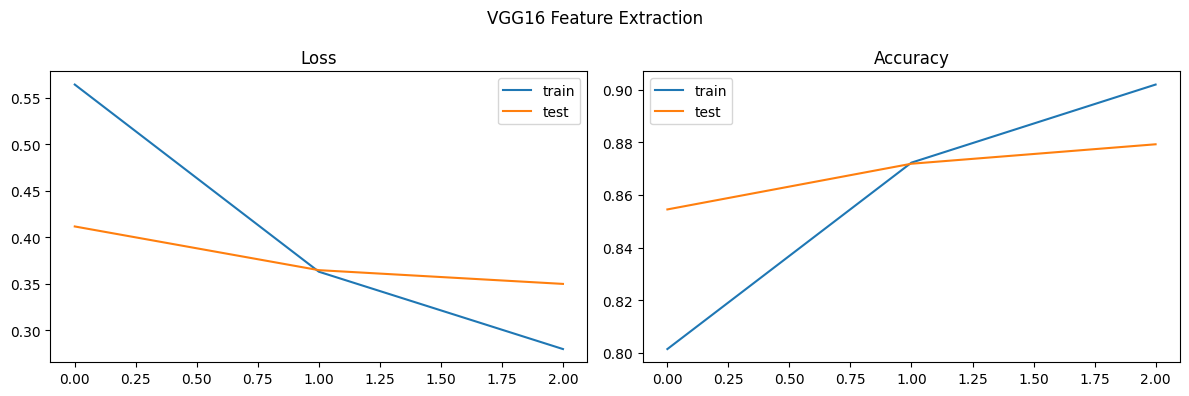

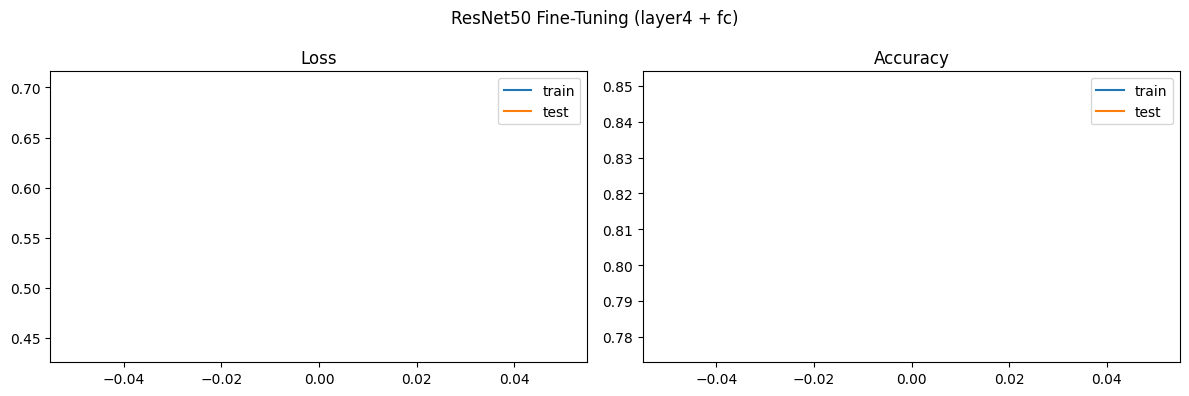

In [9]:
def plot_history(hist_dict, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist_dict["train_loss"], label="train")
    ax[0].plot(hist_dict["test_loss"], label="test")
    ax[0].set_title("Loss")
    ax[0].legend()
    ax[1].plot(hist_dict["train_acc"], label="train")
    ax[1].plot(hist_dict["test_acc"], label="test")
    ax[1].set_title("Accuracy")
    ax[1].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(hist_fe, "VGG16 Feature Extraction")
plot_history(hist_ft, "ResNet50 Fine-Tuning (layer4 + fc)")


## Final Comparison (Tutorial)


In [10]:
import pandas as pd

# Re-evaluate for clean numbers
_, acc_fe = evaluate_model(vgg_fe, test_loader, criterion, device)
_, acc_ft = evaluate_model(rn_ft, test_loader, criterion, device)

summary = pd.DataFrame([
    {
        "Method": "VGG16 Feature Extraction",
        "Test Acc": acc_fe,
        "Train Time (s)": t_fe,
        "Trainable Params": count_trainable_parameters(get_vgg16_feature_extractor(10)),
    },
    {
        "Method": "ResNet50 Fine-Tune (layer4)",
        "Test Acc": acc_ft,
        "Train Time (s)": t_ft,
        "Trainable Params": count_trainable_parameters(setup_resnet50_finetune(10)),
    },
])
print(summary.to_string(index=False))


                     Method  Test Acc  Train Time (s)  Trainable Params
   VGG16 Feature Extraction    0.8793     1246.916794         119586826
ResNet50 Fine-Tune (layer4)    0.8504      336.132558          14985226


### Key Takeaways (Tutorial)
- **Feature extraction** = only the new last layers learn; quick and stable.
- **Fine-tuning** = last blocks + head learn; often better accuracy, needs smaller LR on early layers.
- Use **ImageNet** resize + normalize when you use **ImageNet** weights.


---
<a id="lab-exercises-100-marks"></a>
# Lab Exercises (100 marks total)

There are **three exercises**. Each exercise has:
- **Code:** complete the `# TODO` cells (copy patterns from the tutorial).
- **Questions**. Each answer must be at least **100 words**. State your **word count** at the end of each answer.

| Exercise | Topic (Part A) | Approx. marks |
|----------|----------------|---------------|
| **1** | Data augmentation + visualization | **34** |
| **2** | VGG16 feature extraction | **33** |
| **3** | ResNet50 fine-tuning + LR scheduler + save/load | **33** |

**How to work:** Run the **tutorial** first. Use fewer epochs (e.g. 3) while debugging.


## Exercise 1 — Data augmentation & visualization (34 marks)

 Add `RandomHorizontalFlip`, `RandomRotation`, and `ColorJitter` to the training pipeline; build a `DataLoader`; display **10** augmented images in a grid with class labels (denormalize for display).

Answer the **three** questions below (each **≥ 100 words**).

**Tip:** Create a **second** `CIFAR10` dataset with your new transform; same `root='./data'` as the tutorial.


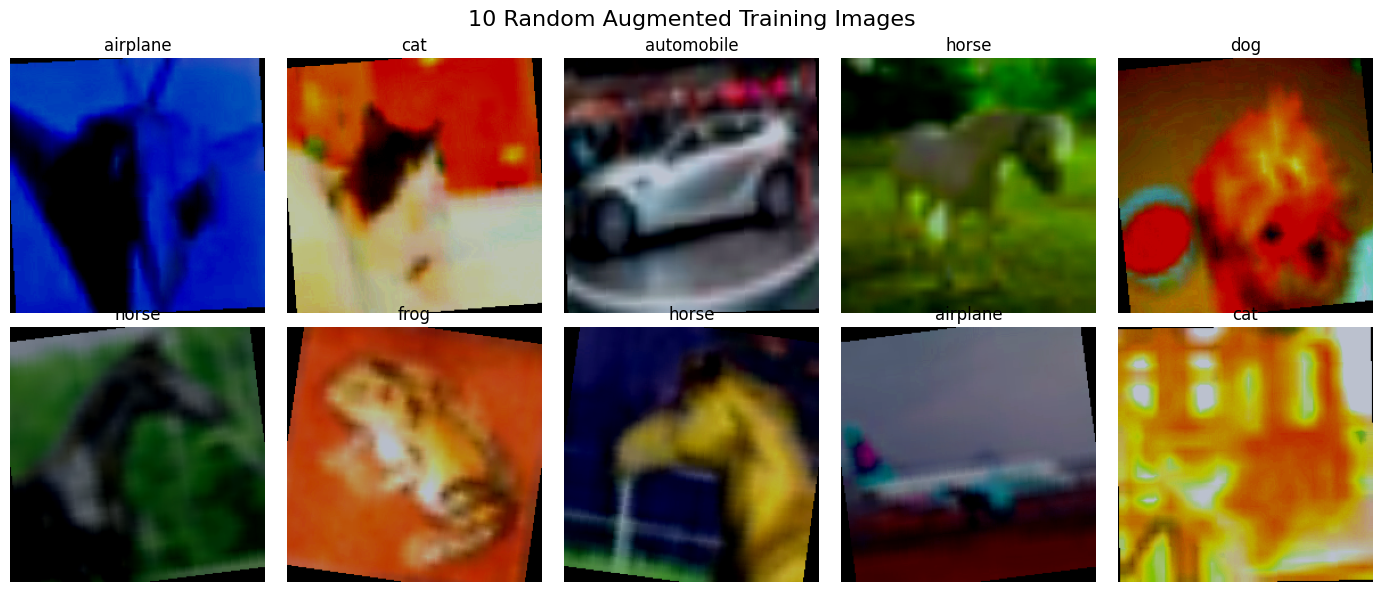

In [15]:
from torchvision.transforms.transforms import ColorJitter
# === YOUR CODE STARTS HERE ===
# Step A — Build transforms (order matters: geometric augments BEFORE ToTensor)
# Step B — Dataset + DataLoader (same pattern as tutorial Step 2)
# Step C — Denormalize for display: tensor * std + mean (use torch.tensor(IMAGENET_STD).view(3,1,1))
# Step D — next(iter(loader)) gets one batch; plot first 10 images in 2 rows × 5 columns


train_transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    # TODO: add RandomHorizontalFlip(), RandomRotation(degrees=...), ColorJitter(...)  (see torchvision docs)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=10, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# TODO: aug_train_set = CIFAR10(root="./data", train=True, download=True, transform=train_transform_aug)
# TODO: aug_train_loader = DataLoader(aug_train_set, batch_size=32, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())

# TODO: denormalize batch for matplotlib (images are normalized — imshow needs roughly 0..1)
# TODO: images, labels = next(iter(aug_train_loader))
# TODO: fig, axes = plt.subplots(2, 5, figsize=(...)); loop i in range(10): show images[i], title = classes[labels[i]]


# === YOUR CODE ENDS HERE ===
aug_train_set = CIFAR10(root='./data', train=True, download=True, transform=train_transform_aug)
aug_train_loader = DataLoader(aug_train_set, batch_size=32, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())

IMAGENET_MEAN_TENSOR = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
IMAGENET_STD_TENSOR = torch.tensor(IMAGENET_STD).view(3, 1, 1)

images, labels = next(iter(aug_train_loader))

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i in range(10):
  img_denorm = images[i]*IMAGENET_STD_TENSOR+IMAGENET_STD_TENSOR
  img_denorm = torch.clamp(img_denorm, 0, 1)
  ax = axes.flat[i]
  ax.imshow(img_denorm.permute(1, 2, 0).numpy())
  ax.set_title(classes[labels[i]])
  ax.axis('off')
plt.suptitle('10 Random Augmented Training Images', fontsize=16)
plt.tight_layout()
plt.show()

### Exercise 1 — Question 1 (≥100 words)

**Prompt:** Explain what **data augmentation** is and why it is commonly used when training (or fine-tuning) CNNs on datasets like CIFAR-10. Discuss how augmentation relates to **overfitting** and **generalization**, and give at least one reason it is still useful even when starting from **pre-trained** ImageNet weights.

*Write your answer below. Minimum 100 words. End with: Word count: ___*


Data Augmentation is technique where data will be augmented or morphed in order to make new data instead of searching new. It is commonly used when training (or fine-tuning) CNNs on datasets like CIFAR-10, due to lack of data in cIFAR-10 dataset to CNN and avoid overfitting and make model more generalized and help where has problem with translusion variance.
CNNe asily learn that type if dataset because it is learned from more parametrs than CIFAR-10, its noises, patterns. When it is fine-tuning on small dataset, model can quickly overcalculate useful weights learned on ImageNet by overfitting to narrow set of examples. Augmentation keeps learning process focused on finding general patterns.

Word count:111

## Exercise 2 — VGG16 feature extraction (33 marks)

Train a **VGG16** model in **feature-extraction** mode (`get_vgg16_feature_extractor`), **8 epochs**, LR **0.001**, plot **training curves**, and report **test accuracy**.


Use variable names **`vgg_ex2`** and **`hist_ex2`** for your model and history.


Trainable: 119586826


Ex2_VGG16 Epoch 1/3:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 1: Train Loss=0.5667 Acc=0.8022 | Test Loss=0.3998 Acc=0.8582


Ex2_VGG16 Epoch 2/3:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 2: Train Loss=0.3637 Acc=0.8727 | Test Loss=0.3646 Acc=0.8734


Ex2_VGG16 Epoch 3/3:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 3: Train Loss=0.2764 Acc=0.9032 | Test Loss=0.3408 Acc=0.8807
Training complete in 1286.9s | Best test acc: 0.8807


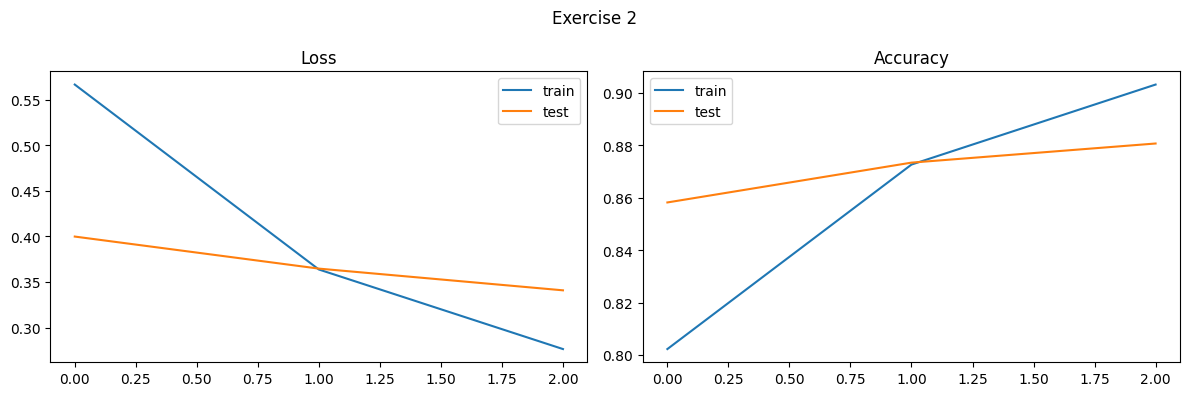

Test acc: 0.8807


In [16]:
# === YOUR CODE STARTS HERE ===
# Copy tutorial Step 5, with new names: vgg_ex2, hist_ex2
# EX2_EPOCHS = 8 for submission; use 3 while debugging on CPU

# TODO: EX2_EPOCHS = 8
# TODO: vgg_ex2 = get_vgg16_feature_extractor(10).to(device)
# TODO: print("Trainable:", count_trainable_parameters(vgg_ex2))
# TODO: opt = optim.SGD(trainable_params(vgg_ex2), lr=0.001, momentum=0.9)
# TODO: vgg_ex2, hist_ex2, _, _ = train_model(vgg_ex2, train_loader, test_loader, criterion, opt, device, num_epochs=EX2_EPOCHS, scheduler=None, model_name="Ex2_VGG16")
# TODO: plot_history(hist_ex2, "Exercise 2")
# TODO: print("Test acc:", evaluate_model(vgg_ex2, test_loader, criterion, device)[1])

# === YOUR CODE ENDS HERE ===
criterion = nn.CrossEntropyLoss()

EX2_EPOCHS = 3

vgg_ex2 = get_vgg16_feature_extractor(10).to(device)
print("Trainable:", count_trainable_parameters(vgg_ex2))

opt = optim.SGD(trainable_params(vgg_ex2), lr=0.001, momentum=0.9)

vgg_ex2, hist_ex2, t_fe, best_fe = train_model(
    vgg_ex2, train_loader, test_loader, criterion, opt, device,
    num_epochs=EX2_EPOCHS, scheduler=None, model_name="Ex2_VGG16"
)

plot_history(hist_ex2, "Exercise 2")
print("Test acc:", evaluate_model(vgg_ex2, test_loader, criterion, device)[1])

### Exercise 2 — Question 1 (≥100 words)

**Prompt:** Explain **feature extraction** in your own words: what parts of VGG16 are **frozen**, what part is **trained**, and **why** we usually freeze early layers when using ImageNet pre-training. Connect this to the idea of **low-level** vs **high-level** features.

*Write your answer below. Minimum 100 words. End with: Word count: ___*


Feature extraction is the process where features are extracted and gradually reduced in spatial dimension using convolution and pooling operations, while preserving and highlighting important information. Last layers, after four are frozen in VGG16 model while first 3 layers are trained. It freezed to reduce computational time and prevent overfitting. Because it learns only universinal patterns. This is because early layers learn universal low-level features such as edges, textures, and simple patterns, which are useful across many tasks. Moreover, ImageNet has millions of images with thousands of classes. While, high-level features learns deeper layers to achieve: adaptation and use to specific tasks.
 Word coumt: 102

## Exercise 3 — ResNet50 fine-tuning, scheduler & checkpoint (33 marks)

Fine-tune **ResNet50** (`setup_resnet50_finetune`): **unfreeze `layer4` + `fc`**, use **two learning rates**, add **`ReduceLROnPlateau`**, train **8 epochs** (use **3** while debugging), plot curves, report test accuracy and final learning rates.

**Also:** Save `ex3_model.state_dict()` to a file, load into a **fresh** model, and **verify** test accuracy matches (see TODOs).

Use **`ex3_model`** and **`hist_ex3`** for your trained model and history.


Ex3_ResNet50 Epoch 1/3:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 1: Train Loss=0.7067 Acc=0.7730 | Test Loss=0.4366 Acc=0.8497


Ex3_ResNet50 Epoch 2/3:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 2: Train Loss=0.4241 Acc=0.8545 | Test Loss=0.3804 Acc=0.8700


Ex3_ResNet50 Epoch 3/3:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 3: Train Loss=0.3524 Acc=0.8783 | Test Loss=0.3455 Acc=0.8832
Training complete in 1010.0s | Best test acc: 0.8832


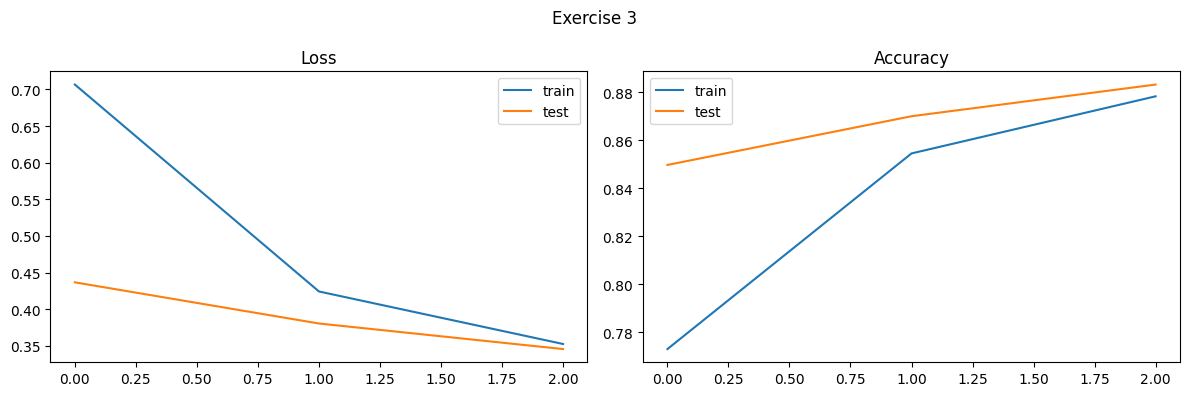

LRs: [0.0001, 0.001]
Test acc: 0.8832
acc before save: 0.8832 | acc after load: 0.8832


In [19]:
# === YOUR CODE STARTS HERE ===
# Copy tutorial Step 6; add ReduceLROnPlateau; use ex3_model, hist_ex3
# Use EX3_EPOCHS = 8 for submission; EX3_EPOCHS = 3 while debugging on CPU

# TODO: EX3_EPOCHS = 8
# TODO: ex3_model = setup_resnet50_finetune(10).to(device)
# TODO: opt_ex3 = optim.SGD([ {"params": ex3_model.layer4.parameters(), "lr": 1e-4}, {"params": ex3_model.fc.parameters(), "lr": 1e-3} ], momentum=0.9)
# TODO: sched_ex3 = optim.lr_scheduler.ReduceLROnPlateau(opt_ex3, mode="min", factor=0.5, patience=2)
# TODO: ex3_model, hist_ex3, _, _ = train_model(ex3_model, train_loader, test_loader, criterion, opt_ex3, device, num_epochs=EX3_EPOCHS, scheduler=sched_ex3, model_name="Ex3_ResNet50")
# TODO: plot_history(hist_ex3, "Exercise 3")
# TODO: print("LRs:", [g["lr"] for g in opt_ex3.param_groups])
# TODO: print("Test acc:", evaluate_model(ex3_model, test_loader, criterion, device)[1])

# --- Save and load (checkpoint) ---
# ckpt_path = "ex3_resnet50.pth"
# TODO: torch.save(ex3_model.state_dict(), ckpt_path)
# TODO: acc_before = evaluate_model(ex3_model, test_loader, criterion, device)[1]
# TODO: loaded = setup_resnet50_finetune(10).to(device)
# TODO: loaded.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=False))
# TODO: acc_after = evaluate_model(loaded, test_loader, criterion, device)[1]
# TODO: print("acc before save:", acc_before, "| acc after load:", acc_after)

# === YOUR CODE ENDS HERE ===

EX3_EPOCHS = 3
ex3_model = setup_resnet50_finetune(10).to(device)
params_ex3 = [
    {"params": ex3_model.layer4.parameters(), "lr": 1e-4},
    {"params": ex3_model.fc.parameters(), "lr": 1e-3}
]
opt_ex3 = optim.SGD(params_ex3, momentum=0.9)
sched_ex3 = optim.lr_scheduler.ReduceLROnPlateau(opt_ex3, mode="min", factor=0.5, patience=2)

ex3_model, hist_ex3, t_ex3, best_ex3 = train_model(ex3_model, train_loader, test_loader, criterion, opt_ex3, device, num_epochs=EX3_EPOCHS, scheduler=sched_ex3, model_name="Ex3_ResNet50")

plot_history(hist_ex3, "Exercise 3")

print("LRs:", [g["lr"] for g in opt_ex3.param_groups])
print("Test acc:", evaluate_model(ex3_model, test_loader, criterion, device)[1])


ckpt_path = "ex3_resnet50.pth"
torch.save(ex3_model.state_dict(), ckpt_path)
acc_before = evaluate_model(ex3_model, test_loader, criterion, device)[1]
loaded = setup_resnet50_finetune(10).to(device)
loaded.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=False))
acc_after = evaluate_model(loaded, test_loader, criterion, device)[1]
print("acc before save:", acc_before, "| acc after load:", acc_after)

### Exercise 3 — Question 1 (≥100 words)

**Prompt:** Explain **fine-tuning** here: why we unfreeze **`layer4`** but keep **`layer1–3`** frozen, and why the **learning rate** for `layer4` is usually **smaller** than for the classifier head. What would likely happen if you used one **large** learning rate for the whole network?

*Write your answer below. Minimum 100 words. End with: Word count: ___*


Fine-tuning is a deep learning technique that takes pre-trained models and turns them into specialized artificial intelligence (AI) models faster than training a new model. In VGG16 fine-tuning, it is keeping layers from 1 to 3 frozen because they capture low-level, general features learned from ImageNet. It unfreezes layer 4 because it learns more task-specific, high-level features, so adjusting it helps adapt to the new dataset. The learning rate for layer 4 is kept smaller to avoid destroying useful pretrained weights, while classifier head uses larger rate since it is newly initialized. If one large learning rate is applied to the whole network, it leads to causing catastrophic forgetting, unstable training,and additionaly, loss of valuable pretrained features.

Word count: 117

---
<a id="conclusion--submission"></a>
# Conclusion & Submission

## Summary of Key Learnings
- Transfer learning adapts ImageNet features to CIFAR-10 efficiently.
- **Feature extraction** trains only the head; **fine-tuning** updates top convolutional blocks with care.
- Matching **normalization**, **image size**, and **learning rates** to the pre-trained model is critical.